In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
iris  = pd.read_csv(r'C:\Users\sbadiger\AI_Practice_Excelr\datasets\iris.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
iris.shape

(150, 5)

In [5]:
iris['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [6]:
iris['species'].nunique()

3

In [7]:
iris['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
data1 = iris.copy()

In [9]:
enc = LabelEncoder()
data1['species'] = enc.fit_transform(data1['species'])

In [10]:
data1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
########### one-hot encoding
from sklearn.preprocessing import OneHotEncoder

In [12]:
data2 = iris.copy()

In [17]:
ohe = OneHotEncoder()
ohe.fit_transform(data2[['species']])   ####### one-hot encoding expects data frame so double brackets

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 150 stored elements and shape (150, 3)>

In [19]:
ohe_data = ohe.fit_transform(data2[['species']]).toarray()
ohe_data

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [22]:
ohe = OneHotEncoder(sparse_output=False)  ###### if we pass sparse_output=False then no need to covert it into array. drop_first=1 - to drop 1st column.
enc_data = ohe.fit_transform(data2[['species']])

In [24]:
enc_df = pd.DataFrame(enc_data, columns=ohe.get_feature_names_out())
enc_df

,species_setosa,species_versicolor,species_virginica
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
145,0.0,0.0,1.0
146,0.0,0.0,1.0
147,0.0,0.0,1.0
148,0.0,0.0,1.0


In [26]:
final_data = data2.join(enc_df)

In [27]:
final_data.drop('species',axis=1,inplace=True)

In [29]:
final_data

,sepal_length,sepal_width,petal_length,petal_width,species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,1.0,0.0,0.0
1,4.9,3.0,1.4,0.2,1.0,0.0,0.0
2,4.7,3.2,1.3,0.2,1.0,0.0,0.0
3,4.6,3.1,1.5,0.2,1.0,0.0,0.0
4,5.0,3.6,1.4,0.2,1.0,0.0,0.0
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0.0,0.0,1.0
146,6.3,2.5,5.0,1.9,0.0,0.0,1.0
147,6.5,3.0,5.2,2.0,0.0,0.0,1.0
148,6.2,3.4,5.4,2.3,0.0,0.0,1.0


In [30]:
##get_dummies
data3 = iris.copy()
pd.get_dummies(data3)   ##### instead of using one-hat coding by pandas we can use get_dummies method

,sepal_length,sepal_width,petal_length,petal_width,species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,True,False,False
1,4.9,3.0,1.4,0.2,True,False,False
2,4.7,3.2,1.3,0.2,True,False,False
3,4.6,3.1,1.5,0.2,True,False,False
4,5.0,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,False,False,True
146,6.3,2.5,5.0,1.9,False,False,True
147,6.5,3.0,5.2,2.0,False,False,True
148,6.2,3.4,5.4,2.3,False,False,True


In [31]:
pd.get_dummies(data3,drop_first=True)   ######## To drop 1st column

,sepal_length,sepal_width,petal_length,petal_width,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,False,False
1,4.9,3.0,1.4,0.2,False,False
2,4.7,3.2,1.3,0.2,False,False
3,4.6,3.1,1.5,0.2,False,False
4,5.0,3.6,1.4,0.2,False,False
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,False,True
146,6.3,2.5,5.0,1.9,False,True
147,6.5,3.0,5.2,2.0,False,True
148,6.2,3.4,5.4,2.3,False,True


In [33]:
from sklearn.preprocessing import StandardScaler

In [32]:
#########Scaling
##a. Standardizing
udf = pd.read_csv(r'C:\Users\sbadiger\AI_Practice_Excelr\datasets\Universities.csv',index_col='Univ')
udf.head()


,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,1310,89,22,13,22704,94
CalTech,1415,100,25,6,63575,81
CMU,1260,62,59,9,25026,72
Columbia,1310,76,24,12,31510,88
Cornell,1280,83,33,13,21864,90


In [34]:
scaler =StandardScaler()
scaled_data = scaler.fit_transform(udf)

In [37]:
scaled_df = pd.DataFrame(scaled_data, columns=udf.columns, index=udf.index)
scaled_df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,0.410284,0.657519,-0.889867,0.070260,-0.331413,0.820303
CalTech,1.399259,1.235212,-0.734657,-1.686251,2.560381,-0.644524
CMU,-0.060657,-0.760454,1.024382,-0.933460,-0.167121,-1.658634
Columbia,0.410284,-0.025208,-0.786394,-0.180670,0.291649,0.144229
Cornell,0.127719,0.342414,-0.320766,0.070260,-0.390846,0.369587


In [38]:
##### b. Normalizing
from sklearn.preprocessing import MinMaxScaler

In [39]:
scaler = MinMaxScaler()
scaled_Data = scaler.fit_transform(udf)
scaled_Data

In [41]:
scaled_df = pd.DataFrame(scaled_data, columns=udf.columns, index=udf.index)
scaled_df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,0.410284,0.657519,-0.889867,0.070260,-0.331413,0.820303
CalTech,1.399259,1.235212,-0.734657,-1.686251,2.560381,-0.644524
CMU,-0.060657,-0.760454,1.024382,-0.933460,-0.167121,-1.658634
Columbia,0.410284,-0.025208,-0.786394,-0.180670,0.291649,0.144229
Cornell,0.127719,0.342414,-0.320766,0.070260,-0.390846,0.369587


In [42]:
####Reduce dimensions
##To build the model
from sklearn.decomposition import PCA

In [43]:
udf.columns

Index(['SAT', 'Top10', 'Accept', 'SFRatio', 'Expenses', 'GradRate'], dtype='object')

In [46]:
#### Standardize the data - mandatory for PCA
scaler =StandardScaler()
scaled_data = scaler.fit_transform(udf)
scaled_df = pd.DataFrame(scaled_data, columns=udf.columns, index=udf.index)
scaled_df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,0.410284,0.657519,-0.889867,0.070260,-0.331413,0.820303
CalTech,1.399259,1.235212,-0.734657,-1.686251,2.560381,-0.644524
CMU,-0.060657,-0.760454,1.024382,-0.933460,-0.167121,-1.658634
Columbia,0.410284,-0.025208,-0.786394,-0.180670,0.291649,0.144229
Cornell,0.127719,0.342414,-0.320766,0.070260,-0.390846,0.369587


In [50]:
pmodel = PCA(n_components=6)
pcomps = pmodel.fit_transform(scaled_df)
pdf=pd.DataFrame(pcomps,columns=['PC1','PC2','PC3','PC4','PC5','PC6'], index=udf.index)
pdf

,PC1,PC2,PC3,PC4,PC5,PC6
Univ,,,,,,
Brown,1.009874,-1.064310,0.081066,-0.056951,-0.128754,-0.034650
CalTech,2.822238,2.259045,0.836829,-0.143845,-0.125962,-0.180703
CMU,-1.112466,1.631209,-0.266787,-1.075075,-0.191814,0.345679
Columbia,0.741741,-0.042187,0.060501,0.157208,-0.577611,0.109163
Cornell,0.311912,-0.635244,0.010241,-0.171364,0.012726,-0.016921
Dartmouth,1.696691,-0.344363,-0.253408,-0.012564,-0.052661,-0.027166
Duke,1.246821,-0.490984,-0.032094,0.205644,0.293505,-0.078012
Georgetown,0.338750,-0.785169,-0.493585,-0.039856,-0.544979,-0.155372
Harvard,2.374150,-0.386539,0.116098,0.453366,-0.230108,0.266984


In [51]:
pmodel.explained_variance_ratio_

array([0.76868084, 0.13113602, 0.04776031, 0.02729668, 0.0207177 ,
       0.00440844])

In [52]:
np.cumsum(pmodel.explained_variance_ratio_)

array([0.76868084, 0.89981687, 0.94757718, 0.97487386, 0.99559156,
       1.        ])

In [54]:
### we can go for 6d-3d and still we can retail 95% info
final_data = pdf[['PC1','PC2','PC3']]
final_data

,PC1,PC2,PC3
Univ,,,
Brown,1.009874,-1.064310,0.081066
CalTech,2.822238,2.259045,0.836829
CMU,-1.112466,1.631209,-0.266787
Columbia,0.741741,-0.042187,0.060501
Cornell,0.311912,-0.635244,0.010241
Dartmouth,1.696691,-0.344363,-0.253408
Duke,1.246821,-0.490984,-0.032094
Georgetown,0.338750,-0.785169,-0.493585
Harvard,2.374150,-0.386539,0.116098


In [55]:
#### TSNE for data visualization
from sklearn.manifold import TSNE

In [57]:
data4 = iris.copy()
features = data4.drop('species',axis=1)
features.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [61]:
tmodel = TSNE(n_components=2)
tcomps = tmodel.fit_transform(features)
tdf=pd.DataFrame(tcomps,columns=['TC1','TC2'])
tdf

,TC1,TC2
0,-25.502390,-1.643927
1,-23.042055,-0.994582
2,-22.787239,-2.096912
3,-22.498199,-1.861895
4,-25.574633,-2.148222
...,...,...
145,12.906998,-2.690201
146,11.175390,0.056674
147,12.370533,-1.953276
148,12.948553,-3.651815


In [62]:
tdf['species'] = data4['species']
tdf.head()

,TC1,TC2,species
0,-25.502390,-1.643927,setosa
1,-23.042055,-0.994582,setosa
2,-22.787239,-2.096912,setosa
3,-22.498199,-1.861895,setosa
4,-25.574633,-2.148222,setosa


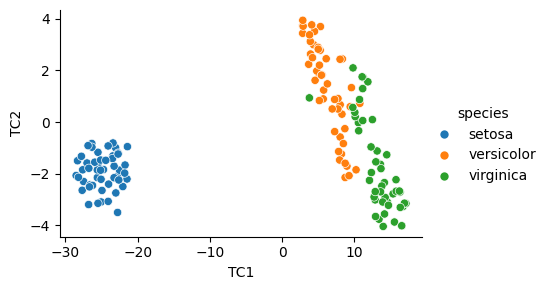

In [67]:
sns.relplot(tdf, x='TC1', y='TC2', kind='scatter', height=3, aspect=1.5, hue='species')
plt.show()